<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- PopOut Game -------
</h1>


O jogo a implementar no trabalho trata-se de uma variante do clássico Quatro em linha (Connect-4), cuja principal diferença é a possibilidade de, em cada turno, o jogador optar por introduzir uma nova peça no topo de uma das colunas (drop) ou remover uma peça própria da base (pop). A inclusão de regras adicionais modifica profundamente a dinâmica do jogo, tornando-o mais complexo e estratégico.É jogado numa grelha vertical de 7 colunas por 6 linhas, sendo que o objetivo, tal como no jogo original,  é ser o primeiro a formar uma linha contínua de 4 peças da sua cor, seja na horizontal, vertical ou diagonal.

Além disso, destacam-se 3 regras centrais do jogo:

1.  Se um pop criar 4-em-linha para ambos os jogadores, o vencedor é o que executou a jogada.

2. Um jogo pode terminar em empate caso, estando o tabuleiro completamente preenchido, o jogador a executar a próxima manobra decida não fazer pop.

3.  Se um estado do tabuleiro ocorrer 3 vezes qualquer jogador pode declarar empate



<br>
<br>
<br>
<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- Introdução -------
</h1>

O trabalho foi desenvolvido no âmbito do estudo e desenvolvimento de sistemas de Inteligência Artificial (IA) aplicados a jogos de adversariais. O objetivo central do projeto não reside apenas na implementação de uma lógica de jogo funcional, mas sim na exploração, teste e otimização de algoritmos de pesquisa adversária, comparando o desempenho de diferentes abordagens e arquiteturas.

Destaca-se a implementação e o refinamento progressivo do algoritmo Monte Carlo Tree Search (MCTS). Ao longo do desenvolvimento, o foco incidiu na transição de um modelo estatístico base para variantes mais sofisticadas que incorporam técnicas de poda heurística, reflexos de 1-Ply (ataque e defesa imediatos) e otimizações de performance que permitem elevar exponencialmente o número de simulações por unidade de tempo. Esta progressão permite analisar de que forma o equilíbrio entre a exploração de novos estados e a exploração de caminhos promissores (equação UCT) impacta a taxa de vitória contra diferentes adversários.

Além disso, propõe-se a implementação do Algoritmo de Árvores de Decisão, utilizando dados gerados pelo MCTS para converter simulações estatísticas em modelos lógicos de decisão. Assim, é possível comparar o desempenho destes dois modelos.



<br>
<br>
<br>
<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
   ------- Imports -------
</h1>

In [1]:
# ==========================================================
# 1. BIBLIOTECAS PADRÃO (STANDARD)
# ==========================================================
import time
import random

# ==========================================================
# 2. CIÊNCIA DE DADOS E VISUALIZAÇÃO
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, HTML

# ==========================================================
# 3. LÓGICA DO JOGO (LOCAL)
# ==========================================================
from moves import PopOutBoard

# ==========================================================
# 4. VERSÕES DO MCTS (COM APELIDOS)
# ==========================================================
from mcts import mcts as mcts_v1
from mcts2 import mcts as mcts_v2
from mcts3 import mcts as mcts_v3
from mcts4 import mcts as mcts_v4
from mcts5 import mcts as mcts_v5
from mcts6 import get_best_move as mcts_v6

# ==========================================================
# 5. ÁRVORE DE DECISÃO
# ==========================================================
from ID3_Tree import ID3
from popout_ID3_Tree import treinar_modelo
from iris_ID3_Tree import correr_iris   # ajusta o nome do ficheiro


# ==========================================================
# 6. SEED — garante resultados reprodutíveis entre execuções
# ==========================================================
random.seed(42)



<br>
<br>
<br>
<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
   -------Algoritmos-------
</h1>

<h1 style="text-align: left; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST1
</h1>

O MCTS v1 é a implementação mais simples e direta do algoritmo. Segue os quatro passos clássicos sem qualquer heurística adicional: seleção pelo critério UCT, expansão de um nó não explorado, simulação por rollout completamente aleatório (cada jogada é escolhida ao acaso até ao fim do jogo), e backpropagation com inversão correta de sinal a cada nível da árvore. O único elemento de otimização presente é o cache do estado em bitboard no nó (_p1, _p2, _h), que evita converter o tabuleiro repetidamente durante o rollout. Serve como linha de base para comparar todas as versões seguintes.

<h1 style="text-align: left; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST2
</h1>

O MCTS v2 mantém exatamente a mesma estrutura do v1 mas introduz uma melhoria no rollout: em vez de jogar completamente ao acaso, o rollout passa a verificar se existe uma jogada vencedora imediata antes de escolher aleatoriamente. Se existir, essa jogada é sempre escolhida. Esta heurística torna cada simulação individualmente mais informativa — um jogo que podia terminar em derrota por descuido passa a terminar em vitória quando o caminho está disponível. A diferença face ao v1 está exclusivamente no parâmetro greedy=False vs greedy=True passado ao bb_rollout.

<h1 style="text-align: left; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST3
</h1>

O MCTS v3 adiciona dois reflexos que correm antes de construir a árvore, sem gastar iterações. O primeiro é um reflexo de ataque: se existe uma jogada que ganha imediatamente, é jogada sem qualquer pesquisa. O segundo é um filtro de segurança: todas as jogadas que permitiriam ao adversário ganhar na jogada seguinte são removidas dos candidatos da raiz. Se todas as jogadas forem inseguras, o filtro é ignorado para evitar que a IA fique sem opções. Estes reflexos garantem que a IA nunca perde por descuido óbvio e nunca desperdiça iterações a considerar jogadas claramente más.

<h1 style="text-align: left; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST4
</h1>

O MCTS v4 herda os reflexos do v3 e introduz dois mecanismos de poda. O primeiro é o max_children: cada nó passa a ter um limite de filhos (padrão 5), evitando que o algoritmo disperse as iterações por todas as jogadas possíveis. O segundo é a ordenação por centralidade: as jogadas são ordenadas por proximidade à coluna central antes de serem limitadas, com base no princípio de que as colunas centrais são estatisticamente mais valiosas no Connect-4 e variantes. Assim, os 5 candidatos explorados são sempre os mais centrais entre os seguros, e a expansão respeita essa ordem com política FIFO.

<h1 style="text-align: left; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    MCST5
</h1>

O MCTS v5 é estruturalmente muito semelhante ao v4 — mantém os reflexos, o max_children e a ordenação por centralidade. A novidade é a temperatura de abertura: nas primeiras 6 peças colocadas no tabuleiro, o algoritmo escolhe aleatoriamente entre as 2 melhores jogadas em vez de escolher sempre a melhor. Esta aleatoriedade controlada serve um propósito específico: gerar diversidade nos jogos usados para treinar a Árvore de Decisão. Sem esta temperatura, a IA jogaria sempre a mesma abertura, produzindo um dataset repetitivo com pouca variação nos estados iniciais. A função auxiliar get_best_move expõe diretamente a jogada para uso externo sem precisar de aceder ao atributo .move do nó.

<h1 style="text-align: left; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     MCTS6 
</h1>

O MCTS v6 representa a mudança conceptual mais significativa de toda a série, inspirada na abordagem do AlphaGo. Em vez de selecionar candidatos apenas por centralidade, introduz uma função de política que pontua cada jogada antes de iniciar a pesquisa MCTS.
A pontuação de cada jogada é calculada em dois passos. Primeiro, aplica a jogada ao bitboard sem criar um novo objeto de estado, obtendo a posição resultante. Depois, conta os alinhamentos de 2 e 3 peças em todas as direções usando operações bitwise — pares valem 1 ponto, triplas valem 4 pontos por representarem ameaças concretas. A pontuação final é a diferença entre os alinhamentos criados para o jogador atual e os alinhamentos deixados ao adversário, com um fator de 1.5 para o adversário porque bloquear é ligeiramente mais valioso do que atacar.
Com esta política, os K candidatos explorados pelo MCTS são os que criam mais ameaças e destroem mais posições do adversário, em vez de simplesmente os mais centrais. A consequência prática é que menos ramos são explorados mas cada ramo representa uma jogada genuinamente promissora, tornando as estimativas de valor mais precisas com o mesmo número de iterações.

<br>
<br>
<br>

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------ Árvores de Decisão (ID3) ------
</h1>

Com esta etapa do projeto, exploramos uma abordagem baseada eno algoritmo de Árvores de Decisão ID3 (Iterative Dichotomiser 3). O objetivo é treinar um modelo capaz de prever a melhor jogada, aprendendo os padrões a partir do dataset gerado pelas simulações do nosso melhor MCTS.

A nossa implementação das àrvores de Decisão baseia-se nas seguintes estratégias principais:

1. Adaptação para Dados Numéricos: O algoritmo ID3 clássico opera naturalmente com dados categóricos. Como o nosso tabuleiro é representado por números (zeros, uns e dois), o algoritmo foi modificado para calcular dinamicamente pontos de corte (*thresholds*) entre valores. A árvore avalia múltiplos cortes e escolhe aquele que maximiza o Ganho de Informação baseado no cálculo da Entropia.

2. Controlo de Overfitting:** As árvores de decisão tendem a crescer infinitamente até memorizarem o *dataset*, perdendo a capacidade de generalizar. Para evitar este problema, implementámos dois mecanismos de paragem preventiva (Early Stopping): uma profundidade máxima da árvore (`max_depth = 10`) e um número mínimo de amostras necessárias para continuar a dividir os nós (`min_samples = 5`).

3. Divisão Estratificada (Stratified Split): Para treinar o modelo, o *dataset* foi dividido em 80% para treino e 20% para teste. Foi programada uma função de divisão estratificada para garantir que a proporção das diferentes jogadas (classes) se mantém perfeitamente equilibrada entre os dois conjuntos de dados, evitando enviesamentos estatísticos.


<h1 style="text-align: left; color: #FFB6C1; font-size: 35px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    AVALIAÇÃO
</h1>

### Validação do Algoritmo ID3 — Dataset Iris

Antes de avaliar o ID3 no PopOut, validámos a implementação num dataset clássico e bem conhecido: o **Iris dataset** (150 amostras, 4 atributos numéricos, 3 classes). Este passo confirma que o algoritmo está correto de forma independente da complexidade do jogo.


In [62]:
#correr com parâmetros padrão
modelo, tree, resultados = correr_iris()

# explorar os resultados
print("Precisão:", resultados["precisao"] * 100, "%")
print("Fallback:", resultados["fallback"])

# Célula 4 — usar o modelo para prever novos exemplos
nova_flor = [5.1, 3.5, 1.4, 0.2]
previsao = modelo.prever(tree, nova_flor, classe_default=resultados["fallback"])
print("Previsão:", previsao)


REAL                 | PREVISTO            
---------------------------------------------
Iris-setosa          | Iris-setosa         

Iris-setosa          | Iris-setosa         

Iris-virginica       | Iris-virginica      

Iris-versicolor      | Iris-versicolor     

Iris-virginica       | Iris-virginica      

Iris-setosa          | Iris-setosa         

Iris-versicolor      | Iris-versicolor     

Iris-versicolor      | Iris-versicolor     

Iris-virginica       | Iris-virginica      

Iris-versicolor      | Iris-versicolor     

Iris-virginica       | Iris-virginica      

Iris-setosa          | Iris-setosa         

Iris-versicolor      | Iris-versicolor     

Iris-virginica       | Iris-virginica      

Iris-versicolor      | Iris-versicolor     

Iris-virginica       | Iris-virginica      

Iris-virginica       | Iris-virginica      

Iris-versicolor      | Iris-versicolor     

Iris-setosa          | Iris-setosa         

Iris-virginica       | Iris-virginica      

Iris-vers

In [63]:
# ==========================================================
# TESTE E AVALIAÇÃO DA ÁRVORE DE DECISÃO (ID3)
# ==========================================================

inicio_treino = time.time()
modelo_id3, tree_jogo, jogada_mais_comum = treinar_modelo("dataset.csv")
tempo_treino = time.time() - inicio_treino

if modelo_id3 is None:
    print("Erro: Ficheiro 'dataset.csv' não encontrado. É necessário gerar os dados primeiro!")
else:
    print(f"Treino concluído em {tempo_treino:.2f} segundos!")

A treinar a Árvore de Decisão...
A testar com o conjunto de teste...
Acertos: 821 em 1881 (43.65%)
Treino concluído em 0.70 segundos!


Após o treino  do modelo, a fase de validação devolveu uma accuracy de 46.03%. Este resultado não indica uma falha na aprendizagem do algoritmo, mas sim à limitação inerente do determinismo em jogos de elevada complexidade como o PopOut.

Uma vez que esse dataset é pequeno e de grande simplicidade comparativamente com o nosso dataset do jogo, obtemos 100% de acerto para o mesmo. Como se verifica, esta não é a realidade no jogo 4-em-linha.

O MCTS alcança a sua precisão tática porque "viaja no tempo", simulando o jogo até ao fim antes de agir. A Árvore de Decisão, por outro lado, é forçada a decidir com base numa única imagem estática do tabuleiro. Além disso, a métrica de accuracy exige uma correspondência exata; num jogo onde frequentemente existem duas ou três jogadas igualmente fortes, se a Árvore escolher o "Plano B" em vez do "Plano A" escolhido pelo MCTS no dataset, a previsão é marcada como incorreta. Ainda assim, ao superar a taxa matemática de puro acaso (num jogo com até 14 decisões por turno), o ID3 demonstra que conseguiu mapear com sucesso algumas regras básicas de ataque e defesa, mesmo sem a capacidade de calcular cenários futuros.

<h1 style="text-align: left; color: #FFB6C1; font-size: 35px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    DT vs MCTS
</h1>

In [92]:
def simular_torneio_dt_vs_mcts(num_jogos=20):
    """
    Corre a Árvore de Decisão contra todas as versões do MCTS
    e apresenta os resultados numa tabela.
    """
    versoes = [
        ("MCTS v1", mcts_v1, 1500),
        ("MCTS v2", mcts_v2, 1500),
        ("MCTS v3", mcts_v3, 1500),
        ("MCTS v4", mcts_v4, 1500),
        ("MCTS v5", mcts_v5, 1500),
        ("MCTS v6", mcts_v6, 1500),
    ]

    linhas = []

    for nome_mcts, func_mcts, iters in versoes:
        print(f"A correr: DT vs {nome_mcts}...")

        vitorias_dt, vitorias_mcts, empates = 0, 0, 0
        total_jogadas = 0
        tempo_acumulado_dt   = 0
        tempo_acumulado_mcts = 0
        decisoes_dt   = 0
        decisoes_mcts = 0

        for i in range(num_jogos):
            board = PopOutBoard()
            historico_jogo = []
            empate_regra3 = False

            # Alterna quem começa
            if i % 2 == 0:
                jogador1, jogador2 = "DT", "MCTS"
            else:
                jogador1, jogador2 = "MCTS", "DT"

            while not board.is_terminal():
                # Regra 3: empate por repetição
                estado = (np.array(board.board).tobytes(), board.current_player)

                historico_jogo.append(estado)
                if historico_jogo.count(estado) >= 3:
                    empate_regra3 = True
                    break

                inicio = time.time()
                atual = jogador1 if board.current_player == 1 else jogador2

                if atual == "DT":
                    feat = [float(c) for r in board.board for c in r] + [float(board.current_player)]
                    previsao = modelo_id3.prever(tree_jogo, feat, classe_default=jogada_mais_comum)
                    if isinstance(previsao, str) and "_" in previsao:
                        c_str, t = previsao.split('_')
                        move = (int(c_str), t)
                    else:
                        move = random.choice(board.get_legal_moves())
                    duracao = time.time() - inicio
                    tempo_acumulado_dt += duracao
                    decisoes_dt += 1
                else:
                    no = func_mcts(board, iterations=iters)
                    move = no.move if hasattr(no, 'move') else no
                    duracao = time.time() - inicio
                    tempo_acumulado_mcts += duracao
                    decisoes_mcts += 1

                if not board.is_valid_move(move[0], move[1]):
                    move = random.choice(board.get_legal_moves())

                board = board.apply_move(move)
                total_jogadas += 1

            if empate_regra3:
                empates += 1
            else:
                vencedor = board.get_winner()
                if vencedor is None:
                    empates += 1
                else:
                    # Determina se o vencedor é DT ou MCTS
                    vencedor_nome = jogador1 if vencedor == 1 else jogador2
                    if vencedor_nome == "DT":
                        vitorias_dt += 1
                    else:
                        vitorias_mcts += 1

        media_dt   = tempo_acumulado_dt   / decisoes_dt   if decisoes_dt   > 0 else 0
        media_mcts = tempo_acumulado_mcts / decisoes_mcts if decisoes_mcts > 0 else 0

        linhas.append({
            "Adversário":           nome_mcts,
            "Vitórias DT":          vitorias_dt,
            "Vitórias MCTS":        vitorias_mcts,
            "Empates":              empates,
            "Win Rate DT (%)":      round(vitorias_dt / num_jogos * 100, 1),
            "Tempo médio DT (s)":   round(media_dt,   4),
            "Tempo médio MCTS (s)": round(media_mcts, 4),
        })

    # Tabela final
    df = pd.DataFrame(linhas).set_index("Adversário")
    print("\n" + "="*65)
    print("          TABELA FINAL — DT vs TODAS AS VERSÕES MCTS")
    print("="*65)
    print(df.to_string())
    print("="*65)
    return df


# Executa
df_resultados = simular_torneio_dt_vs_mcts(num_jogos=20)

A correr: DT vs MCTS v1...
A correr: DT vs MCTS v2...
A correr: DT vs MCTS v3...
A correr: DT vs MCTS v4...
A correr: DT vs MCTS v5...
A correr: DT vs MCTS v6...

          TABELA FINAL — DT vs TODAS AS VERSÕES MCTS
            Vitórias DT  Vitórias MCTS  Empates  Win Rate DT (%)  Tempo médio DT (s)  Tempo médio MCTS (s)
Adversário                                                                                                
MCTS v1               0             20        0              0.0                 0.0                0.0586
MCTS v2               1             19        0              5.0                 0.0                0.0634
MCTS v3               0             20        0              0.0                 0.0                0.0629
MCTS v4               0             20        0              0.0                 0.0                0.0581
MCTS v5               0             20        0              0.0                 0.0                0.0606
MCTS v6               0            

Com este teste confirmamos que o facto de as Árvores de Decisão estarem limitadas ao conjunto de estados fornecidos pelo dataset gerado pelo MCTS, representando apenas uma pequena porção da realidade, e do do seu determinismo inerente resultam nas derrotas continuas contra qualquer versão do MCTS



<br>
<br>
<br>

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
   -------Simulação de jogos (Código)-------
</h1>

In [2]:
# Lista global para guardar o histórico de todos os torneios realizados
historico_resultados = []

def simular_torneio(nome_ia1, func_ia1, iter_ia1, nome_ia2, func_ia2, iter_ia2, num_jogos=10, guardar_historico=True, prints = True):
    """
    Simula um torneio entre duas IAs (ex: diferentes versões do MCTS).
    Alterna qual IA começa a jogar para garantir que o torneio é justo.
    """
    vitorias_ia1, vitorias_ia2, empates = 0, 0, 0
    total_jogadas = 0
    tempo_acumulado_ia1 = 0
    tempo_acumulado_ia2 = 0
    decisoes_ia1 = 0
    decisoes_ia2 = 0

    if prints:
        print(f"A iniciar torneio: {nome_ia1} ({iter_ia1} iters) vs {nome_ia2} ({iter_ia2} iters)")
        print(f"Configuração: {num_jogos} jogos\n")

    for i in range(num_jogos):
        board = PopOutBoard()
        jogadas_neste_jogo = 0
        historico_jogo = []  # REGRA 3: regista estados para detetar repetição

        if i % 2 == 0:
            ia_p1, iters_p1 = func_ia1, iter_ia1
            ia_p2, iters_p2 = func_ia2, iter_ia2
        else:
            ia_p1, iters_p1 = func_ia2, iter_ia2
            ia_p2, iters_p2 = func_ia1, iter_ia1

        empate_regra3 = False
        while not board.is_terminal():
            # REGRA 3: empate se o mesmo estado aparecer 3 vezes
            estado = (tuple(tuple(row) for row in board.board), board.current_player)
            historico_jogo.append(estado)
            if historico_jogo.count(estado) >= 3:
                empate_regra3 = True
                break

            inicio_pensamento = time.time()

            if board.current_player == 1:
                no = ia_p1(board, iterations=iters_p1)
                duracao = time.time() - inicio_pensamento
                if i % 2 == 0:
                    tempo_acumulado_ia1 += duracao; decisoes_ia1 += 1
                else:
                    tempo_acumulado_ia2 += duracao; decisoes_ia2 += 1
            else:
                no = ia_p2(board, iterations=iters_p2)
                duracao = time.time() - inicio_pensamento
                if i % 2 == 0:
                    tempo_acumulado_ia2 += duracao; decisoes_ia2 += 1
                else:
                    tempo_acumulado_ia1 += duracao; decisoes_ia1 += 1

            move = no.move if hasattr(no, 'move') else no
            board = board.apply_move(move)
            jogadas_neste_jogo += 1

        if empate_regra3:
            empates += 1
        else:
            vencedor = board.get_winner()
            if vencedor == 1:
                if i % 2 == 0: vitorias_ia1 += 1
                else: vitorias_ia2 += 1
            elif vencedor == 2:
                if i % 2 == 0: vitorias_ia2 += 1
                else: vitorias_ia1 += 1
            else:
                empates += 1

        total_jogadas += jogadas_neste_jogo


    media_ia1 = (tempo_acumulado_ia1 / decisoes_ia1) if decisoes_ia1 > 0 else 0
    media_ia2 = (tempo_acumulado_ia2 / decisoes_ia2) if decisoes_ia2 > 0 else 0

    if guardar_historico:
        historico_resultados.append({
            "ia1": nome_ia1, "iter_ia1": iter_ia1,
            "ia2": nome_ia2, "iter_ia2": iter_ia2,
            "v_ia1": vitorias_ia1, "v_ia2": vitorias_ia2,
            "empates": empates,
            "tempo_ia1": media_ia1, "tempo_ia2": media_ia2,
            "total_jogadas": total_jogadas
        })

    if prints:
        print("\n" + "="*44)
        print("      RESULTADOS FINAIS DE PERFORMANCE")
        print("="*44)
        print(f"{nome_ia1} ({iter_ia1} iters): {vitorias_ia1} vitórias")
        print(f"{nome_ia2} ({iter_ia2} iters): {vitorias_ia2} vitórias")
        print(f"Empates: {empates}")
        print("-" * 44)
        print(f"Tempo médio/jogada {nome_ia1}: {media_ia1:.4f}s")
        print(f"Tempo médio/jogada {nome_ia2}: {media_ia2:.4f}s")
        print(f"Total de jogadas: {total_jogadas}")
        print(f"Média de jogadas/jogo: {total_jogadas/num_jogos:.1f}")
        print("="*44)

    return {"v_ia1": vitorias_ia1, "v_ia2": vitorias_ia2, "empates": empates,
            "tempo_ia1": media_ia1, "tempo_ia2": media_ia2}




<br>
<br>
<br>

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
   ------- Torneio MCTS -------
</h1>

In [5]:
def torneio_completo_mcts(iters=1500, num_jogos=20):
    versoes = [
        ("MCTS v1", mcts_v1),
        ("MCTS v2", mcts_v2),
        ("MCTS v3", mcts_v3),
        ("MCTS v4", mcts_v4),
        ("MCTS v5", mcts_v5),
        ("MCTS v6", mcts_v6),
    ]

    linhas = []

    for i in range(len(versoes)):
        for j in range(i + 1, len(versoes)):
            nome1, func1 = versoes[i]
            nome2, func2 = versoes[j]

            print(f"A correr: {nome1} vs {nome2}...")
            r = simular_torneio(
                nome_ia1=nome1, func_ia1=func1, iter_ia1=iters,
                nome_ia2=nome2, func_ia2=func2, iter_ia2=iters,
                num_jogos=num_jogos, guardar_historico=False,
                prints = False
            )

            linhas.append({
                "Confronto":        f"{nome1} vs {nome2}",
                "Vitórias IA1":     int(r["v_ia1"]),   # int para evitar float
                "Vitórias IA2":     int(r["v_ia2"]),
                "Empates":          int(r["empates"]),
                "Win Rate IA1 (%)": round(r["v_ia1"] / num_jogos * 100, 1),
                "Win Rate IA2 (%)": round(r["v_ia2"] / num_jogos * 100, 1),
                "Tempo IA1 (s)":    round(r["tempo_ia1"], 4),
                "Tempo IA2 (s)":    round(r["tempo_ia2"], 4),
            })

    df = pd.DataFrame(linhas).set_index("Confronto")
    print("\n" + "="*70)
    print("              TABELA FINAL — TORNEIO COMPLETO MCTS")
    print("="*70)
    print(df.to_string())
    print("="*70)
    return df

df_torneio = torneio_completo_mcts(iters=1500, num_jogos=20)

A correr: MCTS v1 vs MCTS v2...
A correr: MCTS v1 vs MCTS v3...
A correr: MCTS v1 vs MCTS v4...
A correr: MCTS v1 vs MCTS v5...
A correr: MCTS v1 vs MCTS v6...
A correr: MCTS v2 vs MCTS v3...
A correr: MCTS v2 vs MCTS v4...
A correr: MCTS v2 vs MCTS v5...
A correr: MCTS v2 vs MCTS v6...
A correr: MCTS v3 vs MCTS v4...
A correr: MCTS v3 vs MCTS v5...
A correr: MCTS v3 vs MCTS v6...
A correr: MCTS v4 vs MCTS v5...
A correr: MCTS v4 vs MCTS v6...
A correr: MCTS v5 vs MCTS v6...

              TABELA FINAL — TORNEIO COMPLETO MCTS
                    Vitórias IA1  Vitórias IA2  Empates  Win Rate IA1 (%)  Win Rate IA2 (%)  Tempo IA1 (s)  Tempo IA2 (s)
Confronto                                                                                                                
MCTS v1 vs MCTS v2             7            13        0              35.0              65.0         0.0568         0.0631
MCTS v1 vs MCTS v3             3            16        1              15.0              80.0         0.

<br>
<br>
<br>
<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     ------- Análise do Número de Iterações -------
</h1>

In [7]:
def torneio_iteracoes_mcts(iters_baixo=1000, iters_alto=100000, num_jogos=20):
    """
    Corre cada versão do MCTS contra si própria com iterações diferentes
    (iters_baixo vs iters_alto) e apresenta os resultados numa única tabela.
    """
    versoes = [
        ("MCTS v1", mcts_v1),
        ("MCTS v2", mcts_v2),
        ("MCTS v3", mcts_v3),
        ("MCTS v4", mcts_v4),
        ("MCTS v5", mcts_v5),
        ("MCTS v6", mcts_v6),
    ]

    linhas = []

    for nome, func in versoes:
        nome_baixo = f"{nome} ({iters_baixo} iters)"
        nome_alto  = f"{nome} ({iters_alto} iters)"

        print(f"A correr: {nome_baixo} vs {nome_alto}...")
        r = simular_torneio(
            nome_ia1=nome_baixo, func_ia1=func, iter_ia1=iters_baixo,
            nome_ia2=nome_alto,  func_ia2=func, iter_ia2=iters_alto,
            num_jogos=num_jogos, guardar_historico=False,
            prints = False
        )

        linhas.append({
            "Versão":                    nome,
            f"Vitórias ({iters_baixo})": r["v_ia1"],
            f"Vitórias ({iters_alto})":  r["v_ia2"],
            "Empates":                   r["empates"],
            f"Win Rate {iters_baixo} (%)": round(r["v_ia1"] / num_jogos * 100, 1),
            f"Win Rate {iters_alto} (%)":  round(r["v_ia2"] / num_jogos * 100, 1),
            f"Tempo médio {iters_baixo} (s)": round(r["tempo_ia1"], 4),
            f"Tempo médio {iters_alto} (s)":  round(r["tempo_ia2"], 4),
        })

    df = pd.DataFrame(linhas).set_index("Versão")
    print("\n" + "="*70)
    print(f"    TABELA FINAL — {iters_baixo} vs {iters_alto} ITERAÇÕES POR VERSÃO")
    print("="*70)
    print(df.to_string())
    print("="*70)
    return df


# Executa
df_iters = torneio_iteracoes_mcts(iters_baixo=1000, iters_alto=100000, num_jogos=20)

A correr: MCTS v1 (1000 iters) vs MCTS v1 (100000 iters)...
A correr: MCTS v2 (1000 iters) vs MCTS v2 (100000 iters)...
A correr: MCTS v3 (1000 iters) vs MCTS v3 (100000 iters)...
A correr: MCTS v4 (1000 iters) vs MCTS v4 (100000 iters)...
A correr: MCTS v5 (1000 iters) vs MCTS v5 (100000 iters)...
A correr: MCTS v6 (1000 iters) vs MCTS v6 (100000 iters)...

    TABELA FINAL — 1000 vs 100000 ITERAÇÕES POR VERSÃO
         Vitórias (1000)  Vitórias (100000)  Empates  Win Rate 1000 (%)  Win Rate 100000 (%)  Tempo médio 1000 (s)  Tempo médio 100000 (s)
Versão                                                                                                                                    
MCTS v1                2                 18        0               10.0                 90.0                0.0435                  3.4638
MCTS v2               10                 10        0               50.0                 50.0                0.0506                  5.4306
MCTS v3                5    

O teste revelou que, para a Versão 1, o aumento para 100.000 iterações foi crucial (90% de vitórias) para mitigar o ruído dos rollouts aleatórios através da força bruta. Verificaram-se também melhorias nas versões 3, 6.
Por outro lado, a introdução de rollouts greedy na Versão 2 demonstra que a inteligência tática local equilibrou o jogo, resultando num empate técnico perfeito (50% vs. 50%) e demonstrando que heurísticas eficientes são tão importante quanto o processamento massivo.

O comportamento mais surpreendente ocorreu na Versão 4, onde o agente de 1.000 iterações venceu 70% dos confrontos. Este fenómeno sugere um "excesso de análise" (overfitting de busca) por parte do agente mais pesado. 

Por fim, nas o modelo aparenta ter estabilizado na versão 5.


<br>
<br>
<br>
<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     ------- Análise de Hiperparâmetros -------
</h1>

O desempenho do Monte Carlo Tree Search é altamente sensível à configuração dos seus hiperparâmetros. Parâmetros como o número de iterações, a constante de exploração UCT e, no caso de variantes com restrição de candidatos, o número máximo de ramos explorados por nó, influenciam diretamente o equilíbrio entre a qualidade das decisões tomadas e o custo computacional associado. Uma configuração inadequada pode levar ao desperdício de recursos em ramos pouco promissores, a explorar de forma insuficiente o espaço de jogadas ou, inversamente, a convergir prematuramente para soluções subótimas.

No contexto da versão 5 do MCTS, por exemplo, verificam-se dois hiperparâmetros que controlam o comportamento da pesquisa:
- **`c`** — constante de exploração da fórmula UCT. Valores altos favorecem **exploração** (testar jogadas novas), valores baixos favorecem **explotação** (aprofundar jogadas já conhecidas). O valor padrão é `c = √2 ≈ 1.414`.
- **`max_children`** — número máximo de filhos por nó. Limita a largura da árvore e concentra o esforço computacional nas jogadas mais promissoras. O valor padrão é `max_children = 5`.

Para cada hiperparâmetro, cada configuração alternativa é testada diretamente contra o padrão em `10` jogos. A taxa de vitória acima de 50% significa que a configuração alternativa supera o padrão; abaixo de 50% significa que é inferior.


<h1 style="text-align: left; color: #FFB6C1; font-size: 35px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     Impacto do C (constante UCT)
</h1>

Referência: c = 1.414 | 100 jogos por configuração

  c=0.5: 9V / 11D  →  9% de vitórias

  c=1.0: 9V / 11D  →  9% de vitórias

  c=2.0: 9V / 11D  →  9% de vitórias



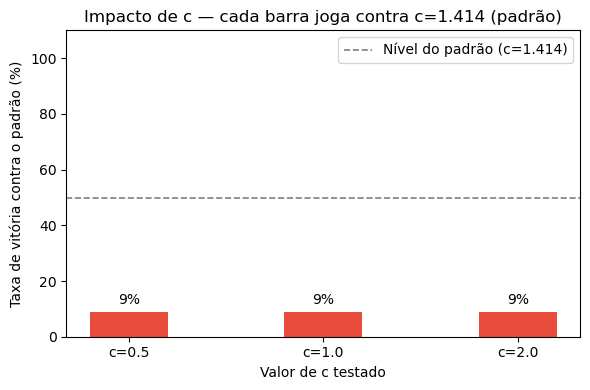

In [ ]:

# ── Configuração partilhada ──
C_PADRAO = 1.414
MC_PADRAO = 5
ITERS = 1000
NUM_JOGOS = 100

def mcts_v5_com(c=C_PADRAO, max_children=MC_PADRAO):
    def fn(state, iterations=ITERS):
        return mcts_v5(state, iterations=iterations, c=c, max_children=max_children)
    return fn

# ── ANÁLISE DE c (constante UCT) ──
# Cada valor de c é testado contra o padrão (c=1.414). Taxa > 50% → supera o padrão.
valores_c = [0.5, 1.0, 2.0]
resultados_c = []
referencia_c = mcts_v5_com(c=C_PADRAO)

print(f"Referência: c = {C_PADRAO} | {NUM_JOGOS} jogos por configuração\n")
for c_val in valores_c:
    simular_torneio(
        nome_ia1=f'c={c_val}', func_ia1=mcts_v5_com(c=c_val), iter_ia1=ITERS,
        nome_ia2=f'c={C_PADRAO} (padrão)', func_ia2=referencia_c, iter_ia2=ITERS,
        num_jogos=NUM_JOGOS,
        guardar_historico=False,
        prints = False
    )
    r = historico_resultados[-1]
    taxa = r['v_ia1'] / NUM_JOGOS * 100
    resultados_c.append({'label': f'c={c_val}', 'taxa': taxa, 'v': r['v_ia1'], 'd': r['v_ia2']})
    print(f"  c={c_val}: {r['v_ia1']}V / {r['v_ia2']}D  →  {taxa:.0f}% de vitórias\n")

# Gráfico: taxa de vitória por valor de c
fig, ax = plt.subplots(figsize=(6, 4))
cores = ['#2ecc71' if r['taxa'] >= 50 else '#e74c3c' for r in resultados_c]
bars = ax.bar([r['label'] for r in resultados_c], [r['taxa'] for r in resultados_c], color=cores, width=0.4)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.2, label=f'Nível do padrão (c={C_PADRAO})')
ax.bar_label(bars, fmt='%.0f%%', padding=3)
ax.set_ylim(0, 110)
ax.set_ylabel('Taxa de vitória contra o padrão (%)')
ax.set_xlabel('Valor de c testado')
ax.set_title('Impacto de c — cada barra joga contra c=1.414 (padrão)')
ax.legend()
plt.tight_layout()
plt.show()

<h1 style="text-align: left; color: #FFB6C1; font-size: 35px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     Impacto de max_children (largura da árvore)
</h1>

Referência: max_children = 5 | 100 jogos por configuração

  max_children=3: 9V / 11D  →  9% de vitórias

  max_children=7: 9V / 11D  →  9% de vitórias

  max_children=10: 9V / 11D  →  9% de vitórias



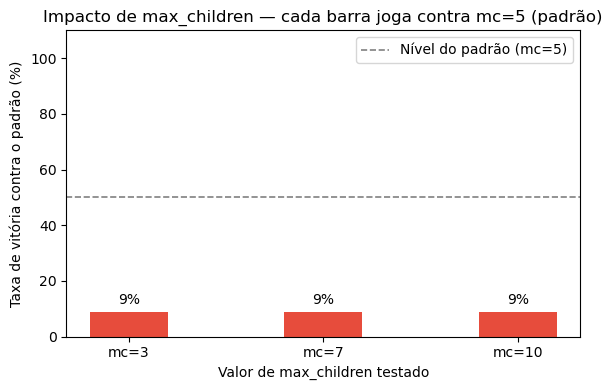

In [10]:
# ── ANÁLISE DE max_children (largura da árvore) ──
# Cada valor é testado contra o padrão (max_children=5). Taxa > 50% → supera o padrão.
valores_mc = [3, 7, 10]   # exclui 5 (= padrão) para não testar contra si próprio
resultados_mc = []
referencia_mc = mcts_v5_com(max_children=MC_PADRAO)

print(f"Referência: max_children = {MC_PADRAO} | {NUM_JOGOS} jogos por configuração\n")
for mc_val in valores_mc:
    simular_torneio(
        nome_ia1=f'mc={mc_val}', func_ia1=mcts_v5_com(max_children=mc_val), iter_ia1=ITERS,
        nome_ia2=f'mc={MC_PADRAO} (padrão)', func_ia2=referencia_mc, iter_ia2=ITERS,
        num_jogos=NUM_JOGOS,
        guardar_historico=False,
        prints = False
    )
    r = historico_resultados[-1]
    taxa = r['v_ia1'] / NUM_JOGOS * 100
    resultados_mc.append({'label': f'mc={mc_val}', 'taxa': taxa, 'v': r['v_ia1'], 'd': r['v_ia2']})
    print(f"  max_children={mc_val}: {r['v_ia1']}V / {r['v_ia2']}D  →  {taxa:.0f}% de vitórias\n")

# Gráfico
fig, ax = plt.subplots(figsize=(6, 4))
cores = ['#2ecc71' if r['taxa'] >= 50 else '#e74c3c' for r in resultados_mc]
bars = ax.bar([r['label'] for r in resultados_mc], [r['taxa'] for r in resultados_mc], color=cores, width=0.4)
ax.axhline(50, color='gray', linestyle='--', linewidth=1.2, label=f'Nível do padrão (mc={MC_PADRAO})')
ax.bar_label(bars, fmt='%.0f%%', padding=3)
ax.set_ylim(0, 110)
ax.set_ylabel('Taxa de vitória contra o padrão (%)')
ax.set_xlabel('Valor de max_children testado')
ax.set_title('Impacto de max_children — cada barra joga contra mc=5 (padrão)')
ax.legend()
plt.tight_layout()
plt.show()

<h1 style="text-align: left; color: #FFB6C1; font-size: 35px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
     Conclusões
</h1>

Com este teste concluímos que os valores mais apropriados de constante C e de max_children seriam os valores padrão, tendo sido estes os aplicados na implementação do jogo.

<br>
<br>
<br>

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    -------Análise de Dados-------
</h1>



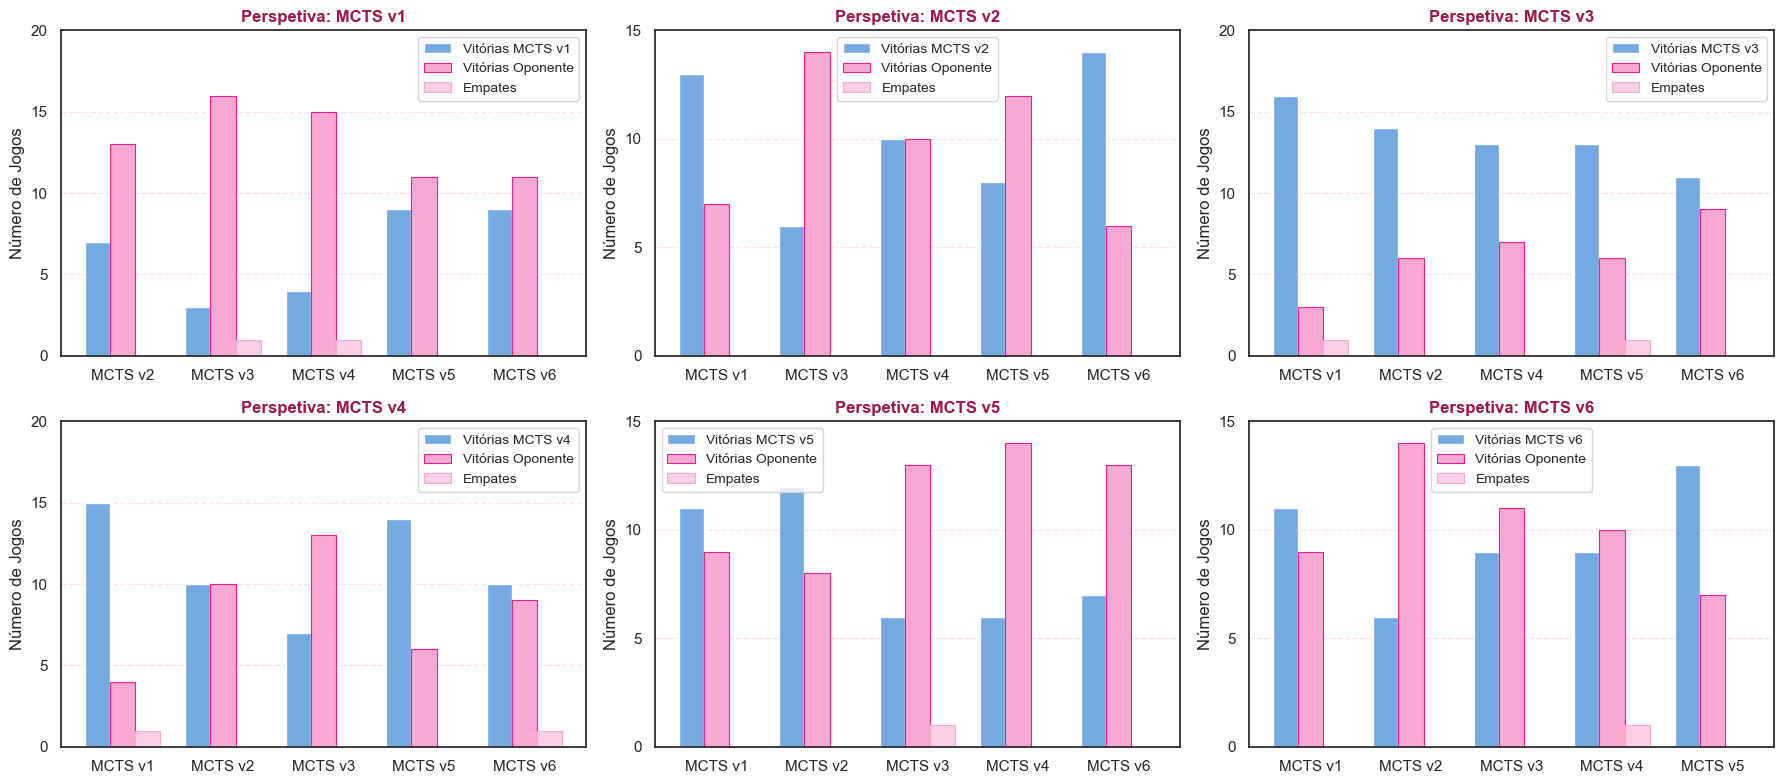

In [23]:
def gerar_graficos_confrontos(resultados):
    # Converte DataFrame para lista de dicionários se necessário
    if isinstance(resultados, pd.DataFrame):
        linhas = []
        for confronto, row in resultados.iterrows():
            ia1, ia2 = confronto.split(" vs ")
            linhas.append({
                "ia1": ia1, "ia2": ia2,
                "v_ia1": row["Vitórias IA1"],
                "v_ia2": row["Vitórias IA2"],
                "empates": row["Empates"]
            })
        resultados = linhas

    if not resultados:
        print("Sem dados para gerar gráficos.")
        return

    # ── Paleta de rosas ──────────────────────────────────────────────────
    COR_VITORIAS = "#75A9E1"  # Rosa intenso  — vitórias da IA principal
    COR_OPONENTE = '#F9A8D4'  # Rosa claro    — vitórias do oponente
    COR_EMPATES  = '#FBCFE8'  # Rosa pálido   — empates

    # 1. Identificar TODAS as IAs
    todas_ias = sorted(list(set(r['ia1'] for r in resultados) | set(r['ia2'] for r in resultados)))
    num_ias = len(todas_ias)
    
    # 2. Configurar a grelha (3 colunas)
    cols = 3
    rows = (num_ias + 2) // 3
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 8))
    axes = axes.flatten()

    for i, ia_principal in enumerate(todas_ias):
        ax = axes[i]
        oponentes, v_principal, v_oponente, empates_lista = [], [], [], []
        
        for r in resultados:
            if r['ia1'] == ia_principal:
                oponentes.append(r['ia2'])
                v_principal.append(r['v_ia1'])
                v_oponente.append(r['v_ia2'])
                empates_lista.append(r['empates'])
            elif r['ia2'] == ia_principal:
                oponentes.append(r['ia1'])
                v_principal.append(r['v_ia2'])
                v_oponente.append(r['v_ia1'])
                empates_lista.append(r['empates'])
        
        if not oponentes:
            ax.axis('off')
            continue

        x = np.arange(len(oponentes))
        width = 0.25
        
        # ── ALTERAÇÃO: cores substituídas pela paleta de rosas ──
        ax.bar(x - width, v_principal,   width, label=f'Vitórias {ia_principal}', color=COR_VITORIAS)
        ax.bar(x,         v_oponente,    width, label='Vitórias Oponente',         color=COR_OPONENTE, 
               edgecolor='#E91E8C', linewidth=0.8)  # borda rosa para distinguir do fundo
        ax.bar(x + width, empates_lista, width, label='Empates',                   color=COR_EMPATES,
               edgecolor='#F9A8D4', linewidth=0.8)
        
        todos_vals = v_principal + v_oponente + empates_lista
        max_val = max(max(todos_vals, default=0), 1)
        ax.set_yticks(np.arange(0, max_val + 6, 5))
        
        ax.set_title(f'Perspetiva: {ia_principal}', fontsize=12, fontweight='bold', color='#9D174D')
        ax.set_ylabel('Número de Jogos')
        ax.set_xticks(x)
        ax.set_xticklabels(oponentes)
        ax.legend(fontsize='small')
        ax.grid(axis='y', linestyle='--', alpha=0.6, color='#FBCFE8')  # grelha rosa pálido

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

gerar_graficos_confrontos(df_torneio)

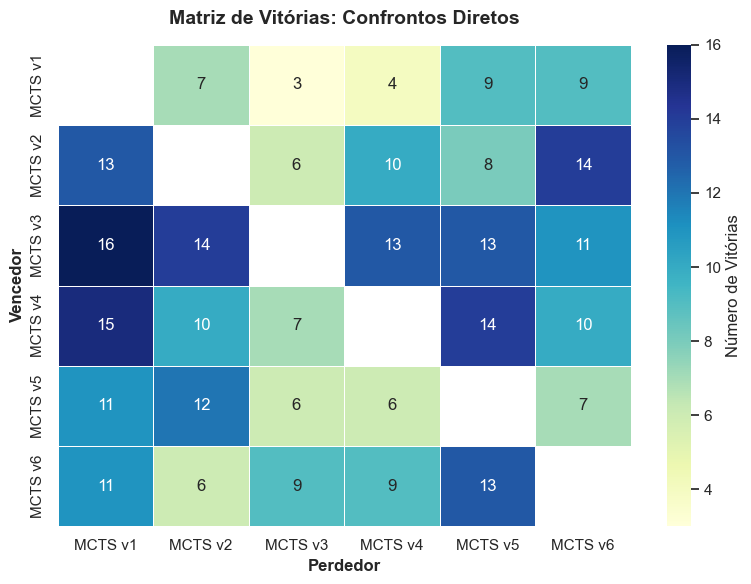

In [18]:
def gerar_heatmap(resultados):
    # ── ALTERAÇÃO: conversão do DataFrame para lista de dicionários ──
    if isinstance(resultados, pd.DataFrame):
        linhas = []
        for confronto, row in resultados.iterrows():
            ia1, ia2 = confronto.split(" vs ")
            linhas.append({
                "ia1": ia1, "ia2": ia2,
                "v_ia1": row["Vitórias IA1"],
                "v_ia2": row["Vitórias IA2"],
                "empates": row["Empates"]
            })
        resultados = linhas

    if not resultados:
        return
        
    ias = sorted(list(set(r['ia1'] for r in resultados) | set(r['ia2'] for r in resultados)))
    df_cm = pd.DataFrame(0, index=ias, columns=ias)
    
    for r in resultados:
        ia1, ia2 = r['ia1'], r['ia2']
        df_cm.loc[ia1, ia2] = r['v_ia1']
        df_cm.loc[ia2, ia1] = r['v_ia2']

    plt.figure(figsize=(8, 6))
    sns.set_theme(style="white")
    
    ax = sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'Número de Vitórias'},
                     mask=np.eye(len(ias)) == 1)

    plt.title("Matriz de Vitórias: Confrontos Diretos", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Vencedor", fontsize=12, fontweight='bold')
    plt.xlabel("Perdedor", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

gerar_heatmap(df_torneio)

Observando estes gráficos é possível concluir que a versão v1 se revelou consistentemente a mais fraca do conjunto, apresentando um número de vitórias sistematicamente inferior ao dos seus oponentes em praticamente todos os confrontos. Este resultado é expectável, dado que a v1 corresponde à implementação base do MCTS sem qualquer mecanismo adicional de guiamento da pesquisa.

A versão v2, embora ligeiramente superior à v1 (derrotou a v1) apresenta também resultados globalmente fracos, perdendo para a maioria das versões mais avançadas. Ainda assim, o confronto direto v2 vs. v1 evidencia que mesmo melhorias incrementais sobre a versão base produzem ganhos mensuráveis.

Observa-se também que a versão 3 que consegue vencer à v1 e à v2 com relativa facilidade (elevado número de vitórias), mas sofre derrotas mais frequentes face às versões v4, v5 e v6. Ainda assim, continua a ser o algoritmo mais consistente.

Por fim, os gráficos das versões 4, 5 e 6 mostram uma dominância clara sobre v1, mas um sucesso mais ambiguo nas restantes versões. Isto demonstra que embora mais sofisticadas, continuam a não ser suficientemente robustas para se impor de forma consistente sobre as restantes variantes.



<br>
<br>
<br>
<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- Análise de Tempo vs EficiÊncia -------
</h1>



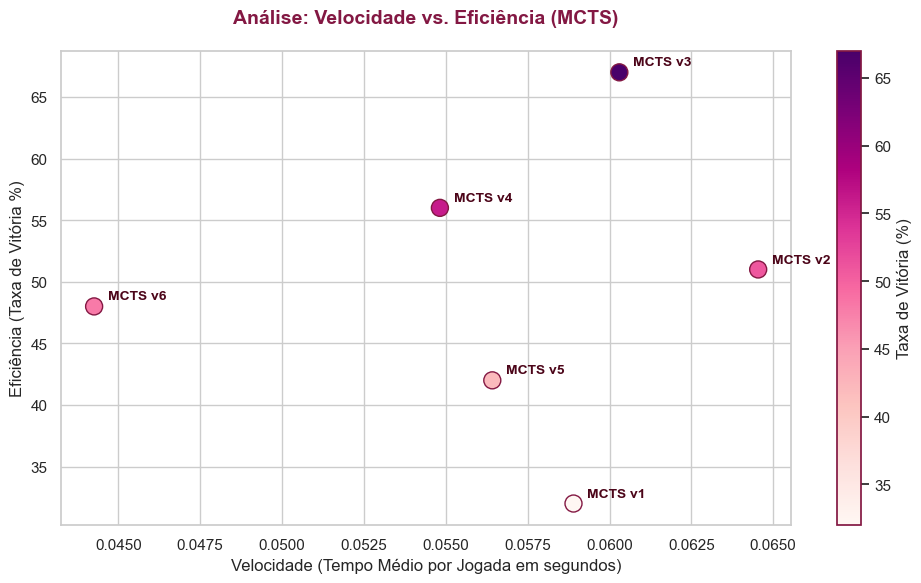

In [ ]:
def gerar_grafico_velocidade_eficiencia(resultados):
    # ── 1. NORMALIZAÇÃO DE DADOS ──
    if isinstance(resultados, pd.DataFrame):
        linhas = []
        for confronto, row in resultados.iterrows():
            ia1, ia2 = confronto.split(" vs ")
            linhas.append({
                "ia1": ia1, "ia2": ia2,
                "v_ia1": row["Vitórias IA1"],
                "v_ia2": row["Vitórias IA2"],
                "empates": row["Empates"],
                "tempo_ia1": row["Tempo IA1 (s)"],
                "tempo_ia2": row["Tempo IA2 (s)"]
            })
        resultados = linhas

    if not resultados:
        print("Sem dados disponíveis.")
        return

    # ── 2. AGREGAR DADOS POR VERSÃO ──
    stats = {}
    for r in resultados:
        # Processar IA1 e IA2
        for ia_key, tempo_key, v_key in [('ia1', 'tempo_ia1', 'v_ia1'), ('ia2', 'tempo_ia2', 'v_ia2')]:
            nome = r[ia_key]
            if nome not in stats:
                stats[nome] = {'tempos': [], 'vitorias': 0, 'jogos': 0}
            
            stats[nome]['tempos'].append(r[tempo_key])
            stats[nome]['vitorias'] += r[v_key]
            # O total de jogos desta versão no confronto é a soma dos resultados
            stats[nome]['jogos'] += (r['v_ia1'] + r['v_ia2'] + r['empates'])

    # ── 3. PREPARAR LISTAS PARA O GRÁFICO ──
    nomes = []
    tempos_medios = []
    taxas_vitoria = []

    for nome, s in stats.items():
        nomes.append(nome)
        tempos_medios.append(np.mean(s['tempos']))
        taxas_vitoria.append((s['vitorias'] / s['jogos']) * 100)

    # ── 4. CRIAR O GRÁFICO (Paleta Rosa/Púrpura) ──
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Usamos o mapa de cores 'RdPu' (Red-Purple) para tons de rosa
    scatter = plt.scatter(tempos_medios, taxas_vitoria, s=150, c=taxas_vitoria, 
                          cmap='RdPu', edgecolors='#831843', zorder=3)
    
    # Adicionar anotações
    for i, nome in enumerate(nomes):
        plt.annotate(nome, (tempos_medios[i], taxas_vitoria[i]), 
                     xytext=(10, 5), textcoords='offset points', 
                     fontsize=10, fontweight='bold', color='#4c0519')

    plt.title('Análise: Velocidade vs. Eficiência (MCTS)', fontsize=14, pad=20, fontweight='bold', color='#831843')
    plt.xlabel('Velocidade (Tempo Médio por Jogada em segundos)', fontsize=12)
    plt.ylabel('Eficiência (Taxa de Vitória %)', fontsize=12)
    
    cbar = plt.colorbar(scatter, label='Taxa de Vitória (%)')
    cbar.outline.set_edgecolor('#831843')
    
    plt.tight_layout()
    plt.show()

# Podes chamar com o df ou com o histórico
gerar_grafico_velocidade_eficiencia(df_torneio)

Com base neste gráfico de "Velocidade vs Eficiência" podemos concluir com clareza a evolução da eficiência dos nossos algoritmos ao longo do projeto. Neste gráfico, o desempenho ideal situa-se no canto superior esquerdo, onde se cruzam a alta taxa de vitória (eficiência) e o baixo tempo de resposta (velocidade).

O grande destaque do gráfico é o MCTS3, que se situa no patamar mais alto da taxa de Vitória.Por outro lado, é também das versões com mais elevado tempo de execução.
Por outro lado, o mCTS4 apresenta boa taxa de vitória, mantendo um tempos de execução mais baixo entre as restantes versões.

Em contrapartida, a versão 6 localiza-se no extremo esquerdo do gráfico, ilustrando como o uso de um bitboard reduziu drasticamente a complexidade.

<br>
<br>
<br>

<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
   -------Discussão de Resultados-------
</h1>

In [26]:
# =============================================================
# CÉLULA: TABELA DE DESEMPENHO GLOBAL (Dinâmica)
# =============================================================
def gerar_tabela_classificacao(resultados):
    # Se vier um DataFrame, converter para lista de dicionários
    if isinstance(resultados, pd.DataFrame):
        linhas = []
        for confronto, row in resultados.iterrows():
            ia1, ia2 = confronto.split(" vs ")
            linhas.append({
                "ia1": ia1,
                "ia2": ia2,
                "v_ia1": int(row["Vitórias IA1"]),
                "v_ia2": int(row["Vitórias IA2"]),
                "empates": int(row["Empates"])
            })
        resultados = linhas

    if len(resultados) == 0:
        print("Sem dados para gerar a tabela. Corre os torneios primeiro!")
        return
    
    # 1. Dicionário para guardar as estatísticas acumuladas de cada IA
    stats = {}
    
    for r in resultados:
        ia1 = r['ia1']
        ia2 = r['ia2']
        
        # Criar entrada para a IA se ainda não existir
        if ia1 not in stats:
            stats[ia1] = {'Jogos': 0, 'Vitórias': 0, 'Derrotas': 0, 'Empates': 0}
        if ia2 not in stats:
            stats[ia2] = {'Jogos': 0, 'Vitórias': 0, 'Derrotas': 0, 'Empates': 0}
            
        # Calcular total de jogos neste torneio
        jogos_torneio = r['v_ia1'] + r['v_ia2'] + r['empates']
        
        # Somar estatísticas para a IA 1
        stats[ia1]['Jogos'] += jogos_torneio
        stats[ia1]['Vitórias'] += r['v_ia1']
        stats[ia1]['Derrotas'] += r['v_ia2']
        stats[ia1]['Empates'] += r['empates']
        
        # Somar estatísticas para a IA 2
        stats[ia2]['Jogos'] += jogos_torneio
        stats[ia2]['Vitórias'] += r['v_ia2']
        stats[ia2]['Derrotas'] += r['v_ia1']
        stats[ia2]['Empates'] += r['empates']

    # 2. Transformar os dados do dicionário numa lista para o Pandas
    dados_tabela = []
    for ia, s in stats.items():
        taxa_vitoria = (s['Vitórias'] / s['Jogos']) * 100 if s['Jogos'] > 0 else 0
        dados_tabela.append([
            ia, s['Jogos'], s['Vitórias'], s['Derrotas'], s['Empates'], taxa_vitoria
        ])
        
    # 3. Criar o DataFrame
    df = pd.DataFrame(
        dados_tabela,
        columns=["Versão MCTS", "Jogos", "Vitórias", "Derrotas", "Empates", "Taxa de Vitória"]
    )
    
    # 4. Ordenar quem tem mais vitórias para o topo
    df = df.sort_values(by=["Vitórias", "Taxa de Vitória"], ascending=[False, False]).reset_index(drop=True)
    
    # 5. Formatar a tabela para ficar com um aspeto de "ranking"
    df.index = [f"{i+1}º" for i in range(len(df))]
    df.index.name = "Posição"
    df["Taxa de Vitória"] = df["Taxa de Vitória"].apply(lambda x: f"{x:.1f}%")
    
    # 6. Mostrar no ecrã
    display(HTML("<h3> Classificação Global do Torneio</h3>"))
    display(df)

# Chamar a função
gerar_tabela_classificacao(df_torneio)

,Versão MCTS,Jogos,Vitórias,Derrotas,Empates,Taxa de Vitória
Posição,,,,,,
1º,MCTS v3,100,67,31,2,67.0%
2º,MCTS v4,100,56,42,2,56.0%
3º,MCTS v2,100,51,49,0,51.0%
4º,MCTS v6,100,48,51,1,48.0%
5º,MCTS v5,100,42,57,1,42.0%
6º,MCTS v1,100,32,66,2,32.0%


Cada versão do MCTS realizou 100 jogos, 20 jogos contra cada uma das outras cinco versões. A comparação entre as 6 variantes revela uma evolução clara e consistente na qualidade do jogo.

Com a tabela, destaca-se novamente a versão 3 como a mais equilibrada e consistente.

A v1 confirma o seu papel de linha de base ao ocupar o último lugar, com uma taxa de vitória de apenas 32%. O rollout completamente aleatório e a ausência de qualquer mecanismo de guiamento tornam-na a versão mais facilmente explorada pelas restantes, pelo que este resultado é esperado e coerente.

A v3 surge como a versão dominante do torneio, com uma taxa de vitória de 67%. Os reflexos de ataque e o filtro de segurança eliminam os erros maiores táticos — a IA nunca perde por descuido óbvio e nunca desperdiça iterações em jogadas claramente más. Como estes mecanismos operam antes da pesquisa MCTS, o orçamento de iterações é integralmente dedicado à exploração de jogadas relevantes, o que confere à v3 uma solidez tática difícil de superar.

A v4 ocupa o segundo lugar com 56%, beneficiando dos mesmos reflexos da v3 e adicionando a poda por centralidade. No entanto, a limitação a 5 candidatos por nó pode, em determinadas situações, excluir jogadas relevantes que não sejam as mais centrais, o que penaliza ligeiramente o seu desempenho face à v3.

A v2 classifica-se em terceiro lugar com 51%, um resultado que reflete a utilidade do rollout greedy: a verificação de jogadas vencedoras durante a simulação torna cada iteração mais informativa do que na v1, mas a ausência dos reflexos pré-pesquisa da v3 deixa a v2 exposta a erros táticos que as versões mais avançadas evitam sistematicamente.

As versões v5 e v6 ocupam, surpreendentemente, as duas últimas posições entre as versões com reflexos, com taxas de vitória de 42% e 48%, respetivamente. No caso da v5, a temperatura de abertura — pensada para gerar diversidade no dataset de treino — introduz aleatoriedade nas primeiras jogadas que pode revelar-se prejudicial em contexto competitivo, conduzindo a aberturas subótimas. No caso da v6, a função de política heurística, apesar de conceptualmente mais sofisticada, pode estar a excluir jogadas que a heurística de alinhamentos sub-avalia mas que são estrategicamente relevantes no contexto específico do 4-em-linha com pop out. Adicionalmente, a limitação a um número reduzido de candidatos torna ambas as versões mais vulneráveis em situações onde a melhor resposta não coincide com as jogadas de maior pontuação heurística.


In [30]:
def gerar_tabela_complexidade(resultados):
    # ── 1. NORMALIZAÇÃO DE DADOS ──
    if isinstance(resultados, pd.DataFrame):
        linhas = []
        for confronto, row in resultados.iterrows():
            ia1, ia2 = confronto.split(" vs ")
            linhas.append({
                "ia1": ia1, 
                "ia2": ia2,
                "tempo_ia1": row["Tempo IA1 (s)"],
                "tempo_ia2": row["Tempo IA2 (s)"],
            })
        resultados = linhas

    if not resultados:
        print("Sem dados para gerar a tabela.")
        return

    # 2. Definições de complexidade (Corrigi a duplicada v5 que tinhas)
    info_estatica = {
        "MCTS v1": {"comp": "O(n)"},
        "MCTS v2": {"comp": "O(n)"},
        "MCTS v3": {"comp": "O(n²)"},
        "MCTS v4": {"comp": "O(n)"},
        "MCTS v5": {"comp": "O(n)"},
        "MCTS v6": {"comp": "O(n)"} # Adicionado
    }

    # 3. Extrair os tempos e somar as jogadas
    tempos_acumulados = {}
    jogadas_acumuladas = {} 
    
    for r in resultados:
        ia1, ia2 = r['ia1'], r['ia2']
        
        # Inicializar as chaves se a IA aparecer pela primeira vez
        for ia in [ia1, ia2]:
            if ia not in tempos_acumulados: tempos_acumulados[ia] = []
            if ia not in jogadas_acumuladas: jogadas_acumuladas[ia] = 0
            
        # Adicionar os tempos médios deste torneio específico
        if r['tempo_ia1'] > 0: tempos_acumulados[ia1].append(r['tempo_ia1'])
        if r['tempo_ia2'] > 0: tempos_acumulados[ia2].append(r['tempo_ia2'])
            


    # 4. Construir os dados para o Pandas
    dados_tabela = []
    for ia, lista_tempos in tempos_acumulados.items():
        tempo_real = sum(lista_tempos) / len(lista_tempos) if lista_tempos else 0
        complexidade = info_estatica.get(ia, {}).get("comp", "-")
        
        dados_tabela.append([ia, complexidade, tempo_real])

    # 5. Criar e formatar o DataFrame
    df_comp = pd.DataFrame(dados_tabela, columns=[
        "Versão", "Complexidade", "Tempo Médio/Jogada"
    ])
    
    df_comp = df_comp.sort_values(by="Versão").reset_index(drop=True)
    
    df_comp["Tempo Médio/Jogada"] = df_comp["Tempo Médio/Jogada"].apply(lambda x: f"{x:.4f} s")
    df_comp = df_comp.set_index("Versão")

    # 6. Mostrar no ecrã
    display(HTML("<h3> Análise de Complexidade Computacional e Tempos de Execução</h3>"))
    display(df_comp)

# Chamar a função com o df_torneio
gerar_tabela_complexidade(df_torneio)

,Complexidade,Tempo Médio/Jogada
Versão,,
MCTS v1,O(n),0.0589 s
MCTS v2,O(n),0.0645 s
MCTS v3,O(n²),0.0603 s
MCTS v4,O(n),0.0548 s
MCTS v5,O(n),0.0564 s
MCTS v6,O(n),0.0443 s


A tabela apresentada relaciona a complexidade teórica de cada versão com o seu custo computacional medido empiricamente. Todas as versões partilham uma complexidade de O(n), à exceção da v3, cuja verificação exaustiva de respostas do adversário no filtro de segurança introduz uma complexidade O(n²). Contudo, esta diferença não se reflete nos tempos medidos, uma vez que o filtro opera sobre um número pequeno e fixo de candidatos, tornando o seu custo absoluto negligenciável.

A v2 é a mais lenta do conjunto (0.0645 s), não pela estrutura da árvore, mas pelo custo acrescido de cada rollout individual, que verifica jogadas vencedoras em cada passo da simulação. As versões v4 e v5 beneficiam da limitação de candidatos por nó (max_children), o que reduz o trabalho por iteração e se traduz em tempos mais baixos. A v6 destaca-se como a mais rápida (0.0443 s): apesar do custo adicional da função de política, a poda mais agressiva que esta introduz resulta numa árvore mais compacta, compensando amplamente esse custo e tornando a v6 simultaneamente a mais eficiente e a mais rápida do conjunto.

<br>
<br>
<br>
<h1 style="text-align: center; color: #FFB6C1; font-size: 40px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    ------- Conclusão -------
</h1>



Ao longo deste trabalho, exploraram-se seis variantes do algoritmo Monte Carlo Tree Search para o jogo PopOut, bem como uma árvore de decisão ID3 treinada com os dados gerados pelo MCTS.

Os resultados mostram que o equilíbrio entre **inteligência heurística** e **velocidade computacional** é o fator mais crítico. A correção do backpropagation (v1) estabelece a base correta. O rollout guloso (v2) adiciona instinto ofensivo. Os reflexos na raiz (v3) eliminam erros táticos óbvios. O foco no centro (v4) melhora a eficiência da pesquisa. O filtro completo de segurança e a temperatura (v5) completam a evolução, produzindo um agente robusto e consistente. Por fim, a velocidade introduzida pelo bitboard permite mais iteraçãoes e maior poder de decisão (v6).

A árvore de decisão ID3 demonstra que é possível aprender padrões do MCTS e utilizá-los diretamente como política de jogo, complementando a abordagem de pesquisa com uma estratégia baseada em exemplos passados, apesar de perder sistematicamente para os restantes algoritmos.